# Retail Supply Chain Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Latex
import warnings

warnings.filterwarnings('ignore')

## Data loading

In [2]:
df = pd.read_excel('../data/Retail-Supply-Chain-Sales-Dataset.xlsx')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.3680,2,0.20,2.5164


In [4]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 9994 rows, 23 columns


## Data cleaning

In [5]:
print('Any duplicates?', df.duplicated().any())

Any duplicates? False


In [6]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Postal Code            0
Region                 0
Retail Sales People    0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Returned               0
Sales                  0
Quantity               0
Discount               0
Profit                 0
dtype: int64


In [7]:
df.drop(columns='Row ID', inplace=True)

### Exploratory Data Analysis

In [8]:
df.dtypes

Order ID                       object
Order Date             datetime64[ns]
Ship Date              datetime64[ns]
Ship Mode                      object
Customer ID                    object
Customer Name                  object
Segment                        object
Country                        object
City                           object
State                          object
Postal Code                     int64
Region                         object
Retail Sales People            object
Product ID                     object
Category                       object
Sub-Category                   object
Product Name                   object
Returned                       object
Sales                         float64
Quantity                        int64
Discount                      float64
Profit                        float64
dtype: object

In [9]:
numerical_cols = df[['Sales', 'Quantity', 'Profit']]

numerical_cols.describe()

,Sales,Quantity,Profit
count,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,28.656896
std,623.245101,2.225110,234.260108
min,0.444000,1.000000,-6599.978000
25%,17.280000,2.000000,1.728750
50%,54.490000,3.000000,8.666500
75%,209.940000,5.000000,29.364000
max,22638.480000,14.000000,8399.976000


In [10]:
# It can only be assumed that profit is a lot lower than expected due to losses

In [11]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print(categorical_columns)

['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Retail Sales People', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Returned']


In [12]:
for i in ['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category', 'Returned']:
    line = "**" + i + ":** "
    for j in df[i].unique():
        line = line + str(j) + ", "
        
    line = line[:-2]
    display(Markdown(line))

**Ship Mode:** Second Class, Standard Class, First Class, Same Day

**Segment:** Consumer, Corporate, Home Office

**Country:** United States

**Region:** South, West, Central, East

**Category:** Furniture, Office Supplies, Technology

**Sub-Category:** Bookcases, Chairs, Labels, Tables, Storage, Furnishings, Art, Phones, Binders, Appliances, Paper, Accessories, Envelopes, Fasteners, Supplies, Machines, Copiers

**Returned:** Not, Yes

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


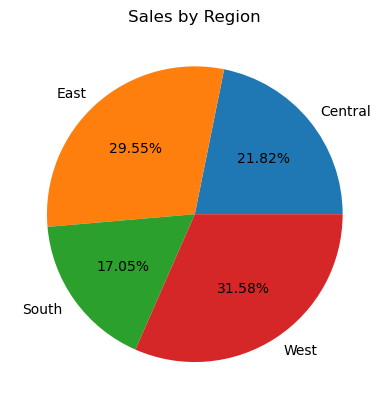

In [14]:
plt.figure()

plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.2f%%')
plt.title('Sales by Region')
plt.show()

In [15]:
# Sales are nicely spread out across the regions

In [16]:
pd.set_option('display.max_colwidth', None)

In [17]:
df.groupby('Category')['Sub-Category'].unique().reset_index()

,Category,Sub-Category
0,Furniture,"[Bookcases, Chairs, Tables, Furnishings]"
1,Office Supplies,"[Labels, Storage, Art, Binders, Appliances, Paper, Envelopes, Fasteners, Supplies]"
2,Technology,"[Phones, Accessories, Machines, Copiers]"


In [18]:
# The retail business focuses on furniture, office supplies, and tech products, with more sub-categories in office supplies

In [19]:
df.groupby('Sub-Category')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders', ascending=False)

,Sub-Category,Total Orders
3,Binders,1523
12,Paper,1370
9,Furnishings,957
13,Phones,889
14,Storage,846
2,Art,796
0,Accessories,775
5,Chairs,617
1,Appliances,466
10,Labels,364


In [20]:
print('Top 10 total orders by product name:')

df.groupby('Product Name')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders', ascending=False).head(10)

Top 10 total orders by product name:


,Product Name,Total Orders
1493,Staple envelope,48
1499,Staples,46
537,Easy-staple paper,46
259,Avery Non-Stick Binders,20
1500,Staples in misc. colors,19
1496,Staple remover,18
942,KI Adjustable-Height Table,18
1511,Storex Dura Pro Binders,17
1497,Staple-based wall hangings,16
993,Logitech 910-002974 M325 Wireless Mouse for Web Scrolling,15


In [21]:
# The sub-categories of binders, paper, and furnishings show a significant number of sales by order from customers
# Staple products seem to be ordered the most from customers

In [22]:
print('Bottom 10 total orders by product name:')

df.groupby('Product Name')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders').head(10)

Bottom 10 total orders by product name:


,Product Name,Total Orders
1227,Panasonic Business Telephones KX-T7736,1
1215,Okidata B401 Printer,1
175,Avaya IP Phone 1140E VoIP phone,1
656,"Fellowes Smart Surge Ten-Outlet Protector, Platinum",1
1225,PNY Rapid USB Car Charger - Black,1
1686,Xerox 1901,1
191,Avery 484,1
1703,Xerox 1918,1
1234,Panasonic KX MB2061 Multifunction Printer,1
1245,Park Ridge Embossed Executive Business Envelopes,1


In [23]:
df.groupby('Category')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders')

,Category,Total Orders
2,Technology,1847
0,Furniture,2121
1,Office Supplies,6026


In [24]:
# Tech products are sold the least

In [25]:
products_sales_top_10 = df.groupby('Product Name')['Sales'].sum().reset_index().rename(columns={'Sales': 'Total Amount'}).sort_values(by='Total Amount', ascending=False).head(10)

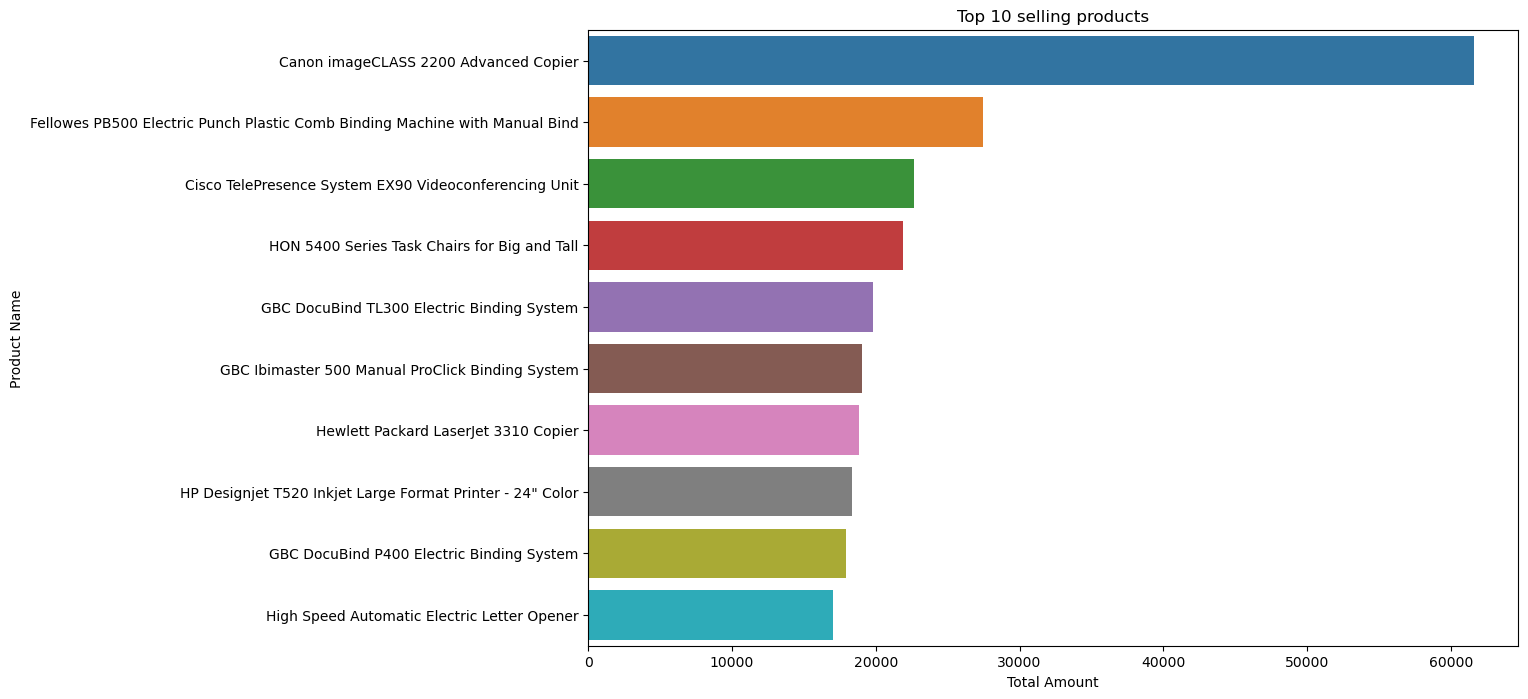

In [26]:
plt.figure(figsize=(12,8))

ax = sns.barplot(products_sales_top_10, x='Total Amount', y='Product Name')
plt.title('Top 10 selling products')
plt.show()

In [27]:
# Tech products sell less, but they sell for a big amount

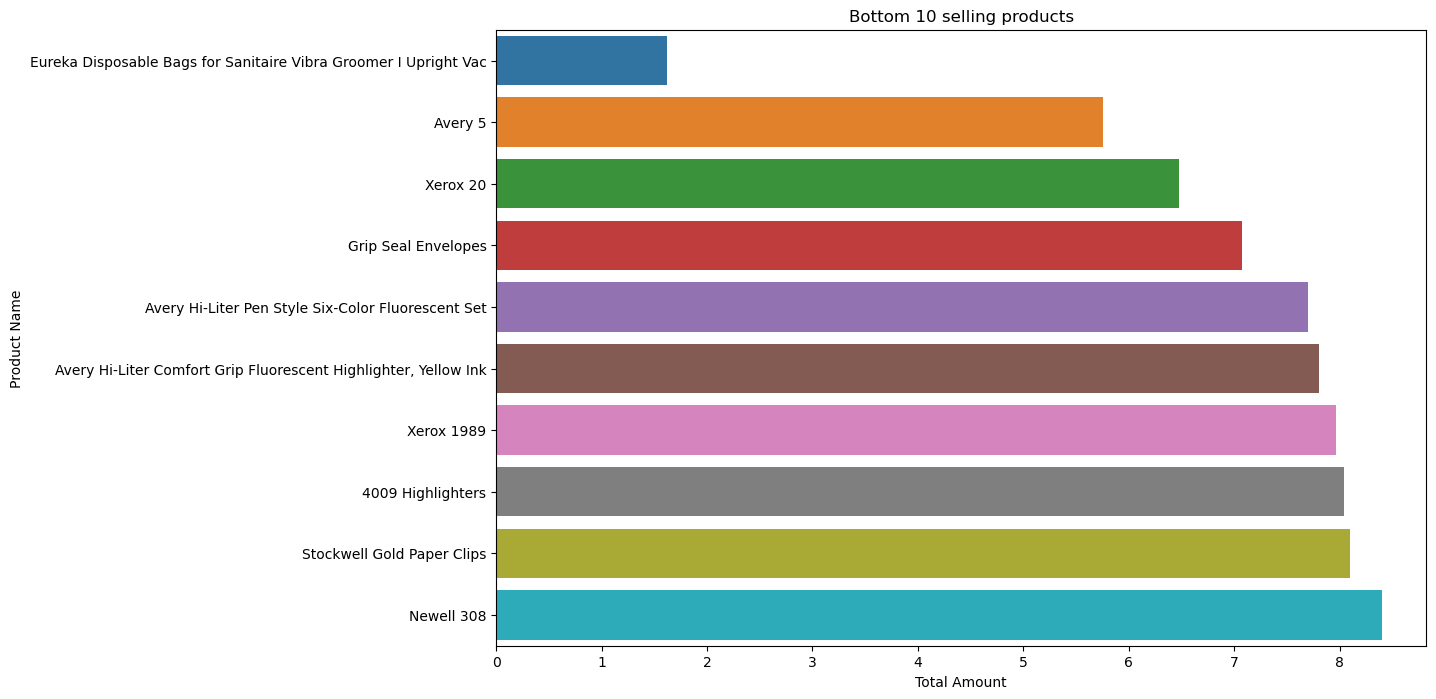

In [28]:
products_sales_bottom_10 = df.groupby('Product Name')['Sales'].sum().reset_index().rename(columns={'Sales': 'Total Amount'}).sort_values(by='Total Amount').head(10)

plt.figure(figsize=(12,8))

ax = sns.barplot(products_sales_bottom_10, x='Total Amount', y='Product Name')
plt.title('Bottom 10 selling products')
plt.show()